In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [3]:
df = pd.read_csv("transactions.csv")
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [4]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [5]:
df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.001920,14.681032,0.285348
std,1848.059224,0.043776,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


### OBSERVATION OF THE DATASET

### count = total number of rows 
### mean and median are roughly symmetric distribution
### std is not highly varied they are moderately in normal distribution
### There is a wide range of difference btw the min and max - 42,089
### The quantiles are not evenly spaced 
### The max and Q3 are varied a lot


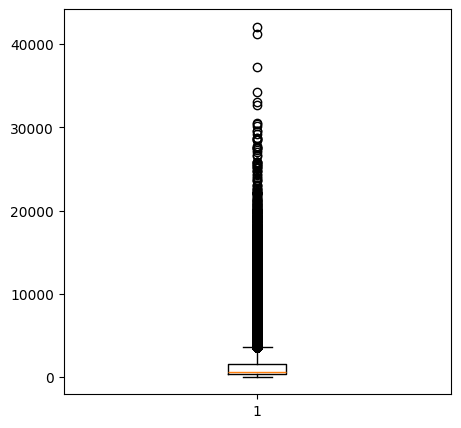

In [11]:
plt.figure(figsize=(5,5))
plt.boxplot(df["amount (INR)"])
plt.show()

In [15]:
#IQR 
q1 = df["amount (INR)"].quantile(0.25)
q3 = df["amount (INR)"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[ (df["amount (INR)"]<lower) | (df["amount (INR)"]>upper) ]
print(len(outliers))

21171


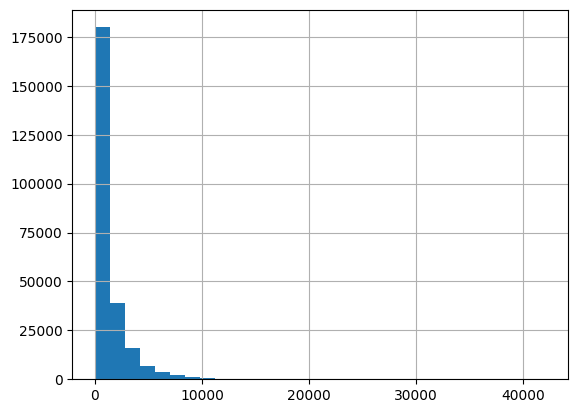

In [13]:
df["amount (INR)"].hist(bins = 30)
plt.show()

<Axes: ylabel='Density'>

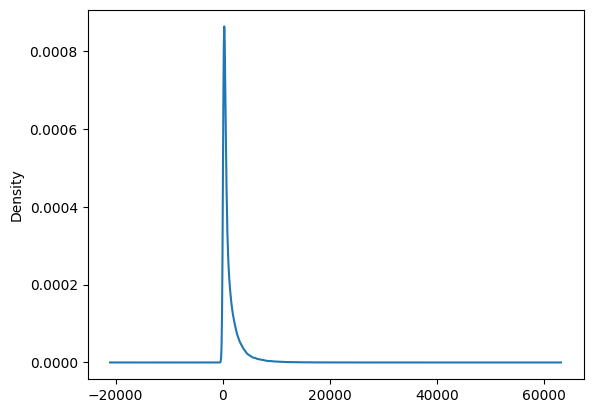

In [14]:
df["amount (INR)"].plot(kind = "density")

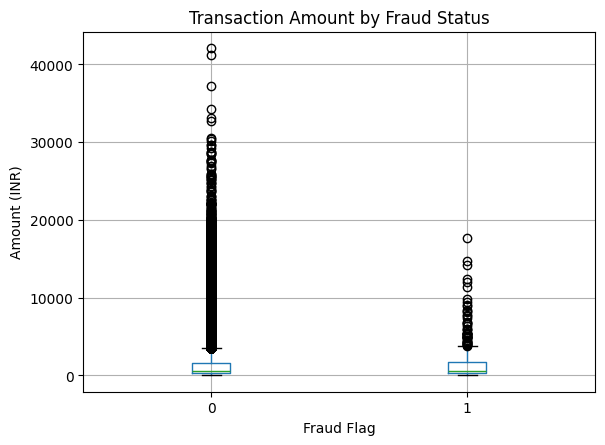

In [18]:
import matplotlib.pyplot as plt

df.boxplot(column="amount (INR)", by="fraud_flag")

plt.title("Transaction Amount by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraud Flag")
plt.ylabel("Amount (INR)")

plt.show()